In [8]:
# ==========================================================
# 0. IMPORT THƯ VIỆN
# ==========================================================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter
from PIL import Image
import cv2

In [9]:
# ==========================================================
# 1. CẤU HÌNH CƠ BẢN
# ==========================================================
DATA_DIR   = r"E:\archive\SkinDisease\SkinDisease"
TRAIN_DIR  = os.path.join(DATA_DIR, "train")
VAL_DIR    = os.path.join(DATA_DIR, "test")

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS     = 100
PATIENCE   = 10
CHECKPOINT_PATH = "mobilenetv3_fulloption_imagenet.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

✅ Using device: cuda


In [10]:
# ==========================================================
# 2. DATA AUGMENTATION
# ==========================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.02),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.20), ratio=(0.3, 3.3)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

📂 Số lớp: 22
🖼️ Số ảnh train: 13898 — val: 1333


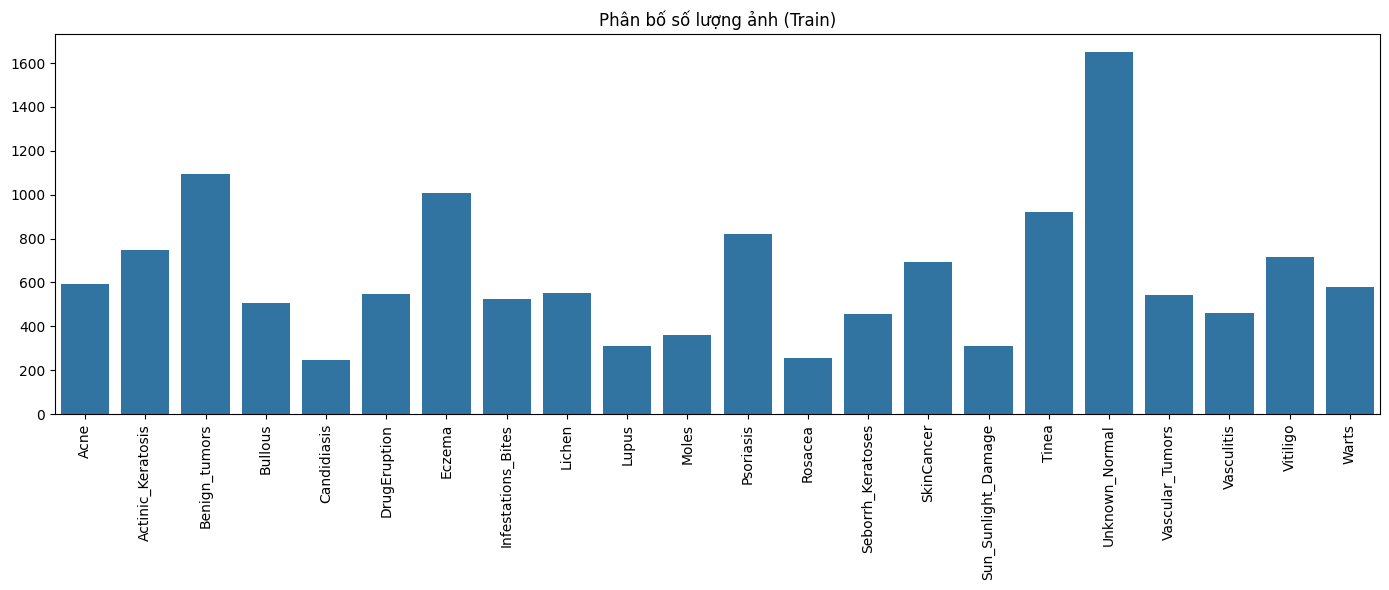

⚖️ Class weights: [1.06530737 0.84455518 0.57797555 1.25342713 2.54728739 1.15489447
 0.62547255 1.2055864  1.14236397 2.0312774  1.74993704 0.77039911
 2.48711525 1.38841159 0.91158337 2.0247669  0.68442825 0.38263311
 1.16340198 1.37034116 0.88477209 1.08918495]


In [11]:
# ==========================================================
# 3. DATASETS & LOADERS
# ==========================================================
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)

print(f"📂 Số lớp: {num_classes}")
print(f"🖼️ Số ảnh train: {len(train_ds)} — val: {len(val_ds)}")

# --- Phân bố nhãn ---
train_labels = [label for _, label in train_ds.samples]
label_counts = Counter(train_labels)

plt.figure(figsize=(14, 6))
sns.barplot(x=[class_names[i] for i in label_counts], y=list(label_counts.values()))
plt.xticks(rotation=90)
plt.title("Phân bố số lượng ảnh (Train)")
plt.tight_layout()
plt.show()

# --- Class weights ---
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

print("⚖️ Class weights:", class_weights_np)

# --- Oversampling ---
class_counts = np.bincount(train_labels)
inv_freq = 1.0 / class_counts
sample_weights = torch.DoubleTensor([inv_freq[i] for i in train_labels])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

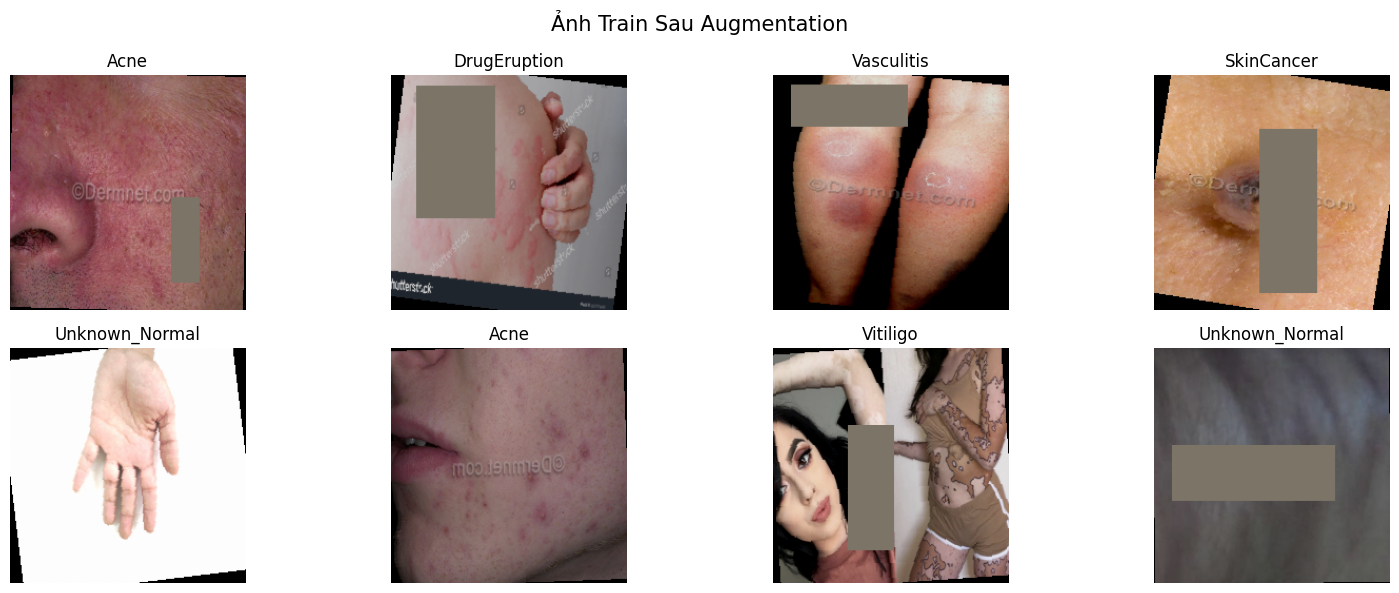

In [12]:
# ==========================================================
# 4. HIỂN THỊ VÀI ẢNH TRAIN (AUGMENTED)
# ==========================================================
def unnormalize(t):
    t = t.clone().cpu().numpy()
    for c in range(3):
        t[c] = t[c]*IMAGENET_STD[c] + IMAGENET_MEAN[c]
    return np.clip(t, 0, 1)

def show_augmented(n=8):
    plt.figure(figsize=(16, 6))
    idxs = random.sample(range(len(train_ds)), n)
    for i, idx in enumerate(idxs):
        img, lbl = train_ds[idx]
        img = unnormalize(img).transpose(1,2,0)

        plt.subplot(2, n//2, i+1)
        plt.imshow(img)
        plt.title(class_names[lbl])
        plt.axis("off")
    plt.suptitle("Ảnh Train Sau Augmentation", fontsize=15)
    plt.tight_layout()
    plt.show()

show_augmented()

In [13]:
# ==========================================================
# 5. FOCAL LOSS
# ==========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

In [ ]:
# ==========================================================
# KHỞI TẠO MOBILENETV3-LARGE PRETRAINED IMAGENET
# ==========================================================
weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
model = models.mobilenet_v3_large(weights=weights)

# Replace classifier head
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

model = model.to(device)
print("✅ MobileNetV3-Large (pretrained=True) initialized.")

criterion = FocalLoss(alpha=class_weights, gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)

✅ MobileNetV3-Large (pretrained=True) initialized.


In [15]:
# ==========================================================
# 7. TRAINING LOOP + EARLY STOPPING
# ==========================================================
best_val_acc = 0
patience_cnt = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, EPOCHS+1):

    # ---------- TRAIN ----------
    model.train()
    total, correct, loss_sum = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} - Train"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = loss_sum / total
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ---------- VAL ----------
    model.eval()
    total, correct, loss_sum = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} - Val", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    val_loss = loss_sum / total
    val_acc  = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss {train_loss:.4f}, Acc {train_acc:.4f} | Val Loss {val_loss:.4f}, Acc {val_acc:.4f}")

    # SAVE BEST MODEL
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("📌 Saved best model.")
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print("⛔ Early stopping.")
            break

# Load best model
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()
print("⭐ Best Val Acc:", best_val_acc)


Epoch 1/100 - Train: 100%|██████████| 435/435 [01:06<00:00,  6.56it/s]


Epoch 1/100 | Train Loss 2.0930, Acc 0.3500 | Val Loss 1.2578, Acc 0.4134
📌 Saved best model.


Epoch 2/100 - Train: 100%|██████████| 435/435 [01:41<00:00,  4.28it/s]


Epoch 2/100 | Train Loss 1.1997, Acc 0.5446 | Val Loss 1.0102, Acc 0.4989
📌 Saved best model.


Epoch 3/100 - Train: 100%|██████████| 435/435 [01:40<00:00,  4.32it/s]


...

Epoch 67/100 - Train: 100%|██████████| 435/435 [01:33<00:00,  4.67it/s]


Epoch 67/100 | Train Loss 0.0099, Acc 0.9875 | Val Loss 0.7700, Acc 0.7764


Epoch 68/100 - Train: 100%|██████████| 435/435 [01:45<00:00,  4.13it/s]


Epoch 68/100 | Train Loss 0.0099, Acc 0.9877 | Val Loss 0.7754, Acc 0.7772
⛔ Early stopping.
⭐ Best Val Acc: 0.7854463615903976


C:\Users\letra\AppData\Local\Temp\ipykernel_25952\2530201238.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH))


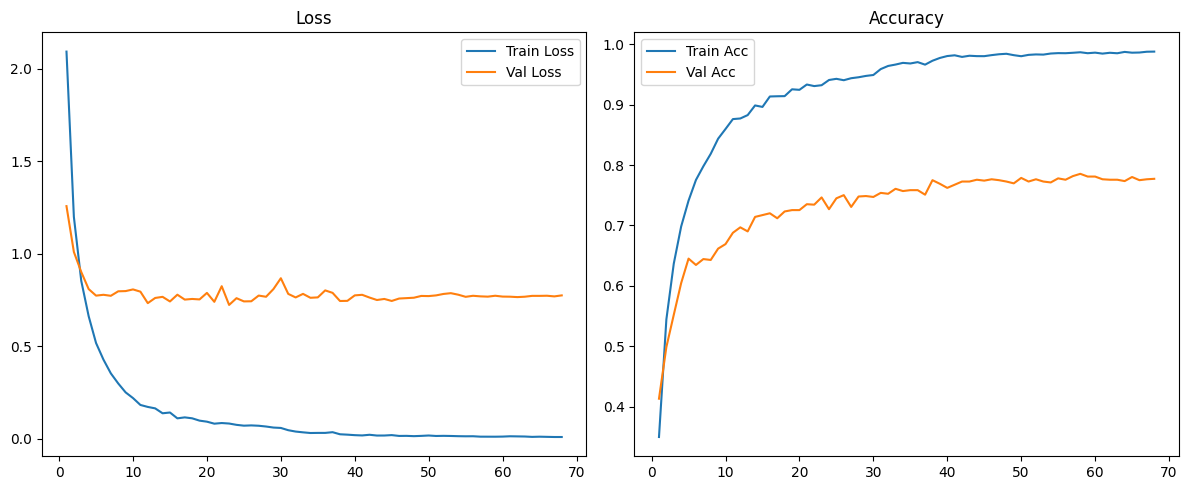

In [16]:
# ==========================================================
# 8. LOSS & ACC CURVES
# ==========================================================
epochs_range = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.legend(), plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accs, label="Train Acc")
plt.plot(epochs_range, val_accs, label="Val Acc")
plt.legend(), plt.title("Accuracy")

plt.tight_layout()
plt.show()


📊 Classification Report:
                     precision    recall  f1-score   support

               Acne       0.92      0.85      0.88        53
  Actinic_Keratosis       0.79      0.78      0.79        73
      Benign_tumors       0.69      0.81      0.75       111
            Bullous       0.61      0.75      0.67        44
        Candidiasis       0.68      0.76      0.72        17
       DrugEruption       0.69      0.65      0.67        51
             Eczema       0.78      0.76      0.77       102
 Infestations_Bites       0.65      0.56      0.60        50
             Lichen       0.73      0.71      0.72        51
              Lupus       0.68      0.54      0.60        24
              Moles       0.75      0.60      0.67        30
          Psoriasis       0.71      0.77      0.74        78
            Rosacea       0.86      1.00      0.92        18
  Seborrh_Keratoses       0.82      0.80      0.81        41
         SkinCancer       0.80      0.70      0.75        

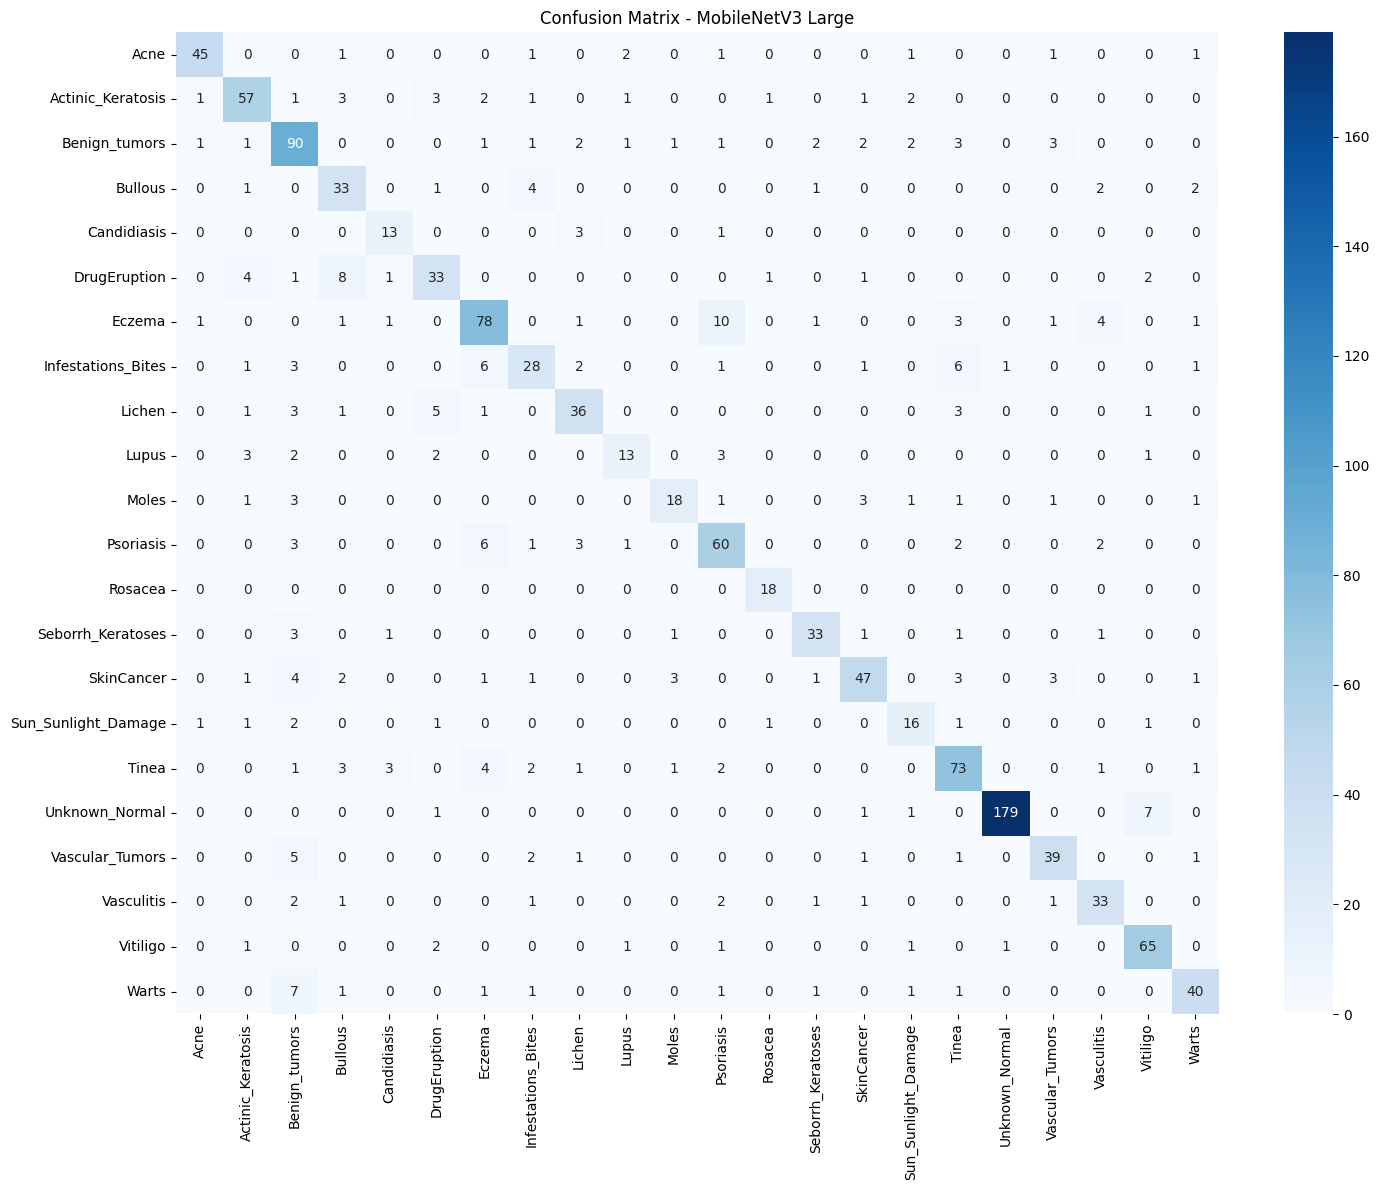

In [17]:
# ==========================================================
# 9. CONFUSION MATRIX + REPORT
# ==========================================================
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outs = model(imgs)
        probs = F.softmax(outs, dim=1)

        _, preds = probs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15,12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Confusion Matrix - MobileNetV3 Large")
plt.tight_layout()
plt.show()


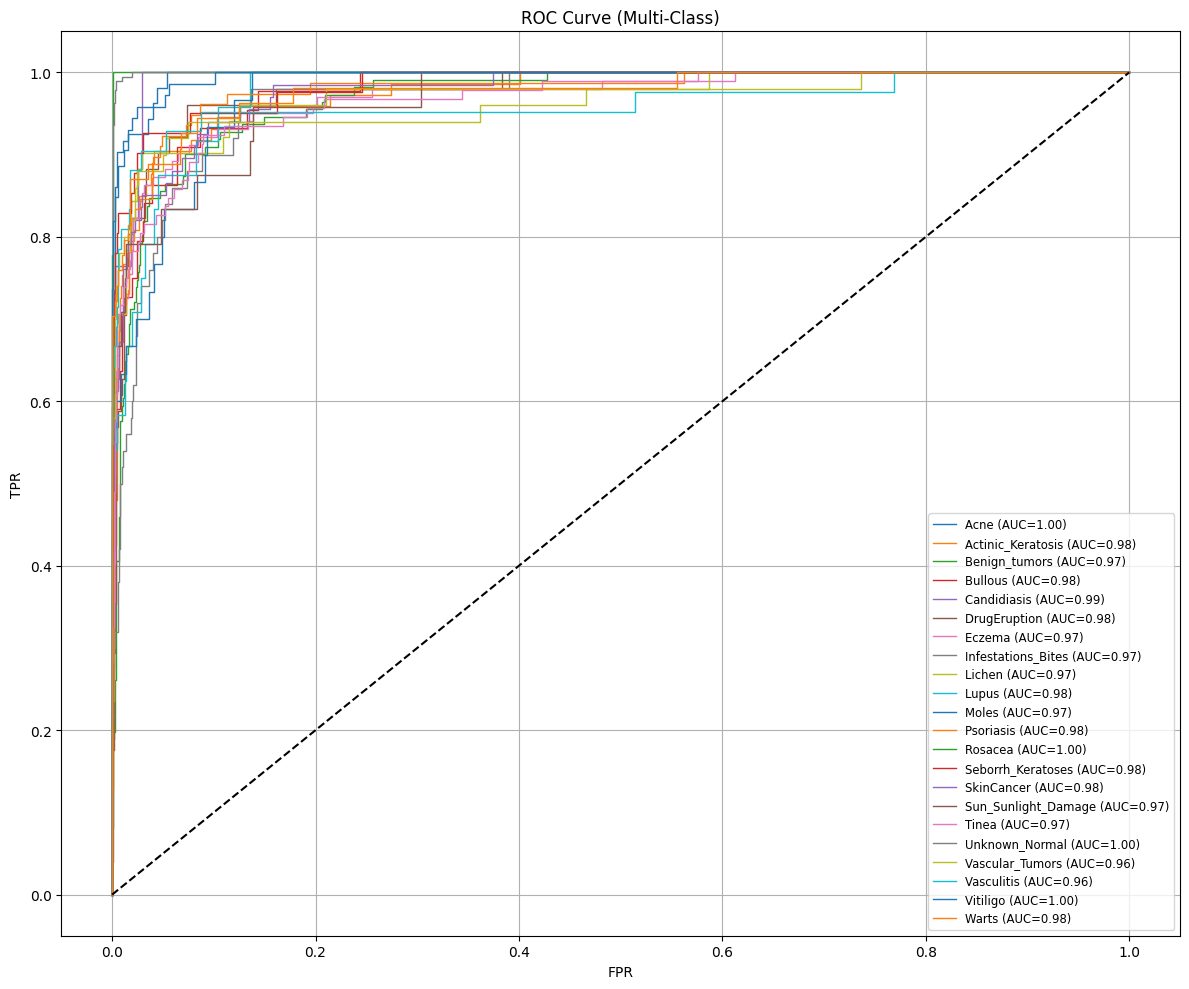

In [18]:
# ==========================================================
# 10. ROC CURVE
# ==========================================================
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
fpr = {}
tpr = {}
roc_auc = {}

y_prob = np.array(y_prob)

plt.figure(figsize=(12,10))
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=1, label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (Multi-Class)")
plt.xlabel("FPR"), plt.ylabel("TPR")
plt.legend(fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()

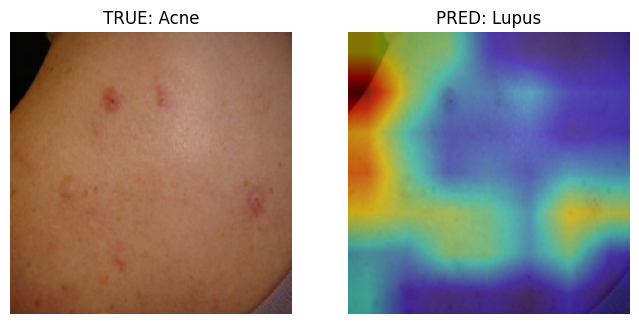

In [30]:
# ==========================================================
# 11. GRAD-CAM (MobileNetV3-Large)
# ==========================================================
target_layer = model.features[-1]  # Conv cuối

activations = {}
gradients = {}

def fwd_hook(m, i, o): activations["value"] = o
def bwd_hook(m, gi, go): gradients["value"] = go[0]

target_layer.register_forward_hook(fwd_hook)
target_layer.register_backward_hook(bwd_hook)

gc_trans = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def show_gradcam(idx=0, dataset=val_ds):
    img_path, lbl = dataset.samples[idx]
    pil = Image.open(img_path).convert("RGB")

    x = gc_trans(pil).unsqueeze(0).to(device)
    model.zero_grad()
    out = model(x)
    pred = out.argmax(1).item()
    out[0, pred].backward()

    acts = activations["value"]
    grads = gradients["value"]

    w = grads.mean(dim=(2,3), keepdim=True)
    cam = (w * acts).sum(dim=1).squeeze().detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
    cam /= cam.max()

    img_np = np.array(pil.resize((IMAGE_SIZE, IMAGE_SIZE)))
    heatmap = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title(f"TRUE: {class_names[lbl]}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title(f"PRED: {class_names[pred]}")
    plt.axis("off")

    plt.show()

# Ví dụ:
show_gradcam(0)